###  Problem statement;
Create an algorithm capable of correctly classify a mashroom as edible or poisonous

In [25]:
# import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


#### read through the dataset
#### delimiter  specifies the character that separates values in the file.


In [26]:
#loading our dataset
mushroom_df = pd.read_csv('./mushroom_data.csv', delimiter=";")

#display first 5 rows
mushroom_df.head(5)

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,...,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,...,s,y,w,u,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,...,s,y,w,u,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,...,s,y,w,u,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,...,s,y,w,u,w,t,p,NaN,d,w


In [27]:
mushroom_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61069 entries, 0 to 61068
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   class                 61069 non-null  object 
 1   cap-diameter          61069 non-null  float64
 2   cap-shape             61069 non-null  object 
 3   cap-surface           46949 non-null  object 
 4   cap-color             61069 non-null  object 
 5   does-bruise-or-bleed  61069 non-null  object 
 6   gill-attachment       51185 non-null  object 
 7   gill-spacing          36006 non-null  object 
 8   gill-color            61069 non-null  object 
 9   stem-height           61069 non-null  float64
 10  stem-width            61069 non-null  float64
 11  stem-root             9531 non-null   object 
 12  stem-surface          22945 non-null  object 
 13  stem-color            61069 non-null  object 
 14  veil-type             3177 non-null   object 
 15  veil-color         

In [28]:
ex_df = mushroom_df[['class', 'cap-diameter', 'stem-height', 'stem-width']]

ex_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61069 entries, 0 to 61068
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   class         61069 non-null  object 
 1   cap-diameter  61069 non-null  float64
 2   stem-height   61069 non-null  float64
 3   stem-width    61069 non-null  float64
dtypes: float64(3), object(1)
memory usage: 1.9+ MB


In [29]:
test_df = pd.get_dummies(ex_df, drop_first=True)
test_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61069 entries, 0 to 61068
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cap-diameter  61069 non-null  float64
 1   stem-height   61069 non-null  float64
 2   stem-width    61069 non-null  float64
 3   class_p       61069 non-null  bool   
dtypes: bool(1), float64(3)
memory usage: 1.5 MB


In [30]:
test_df.head()

,cap-diameter,stem-height,stem-width,class_p
0,15.26,16.95,17.09,True
1,16.60,17.99,18.19,True
2,14.07,17.80,17.74,True
3,14.17,15.77,15.98,True
4,14.64,16.53,17.20,True


In [31]:
test_df.describe()

,cap-diameter,stem-height,stem-width
count,61069.000000,61069.000000,61069.000000
mean,6.733854,6.581538,12.149410
std,5.264845,3.370017,10.035955
min,0.380000,0.000000,0.000000
25%,3.480000,4.640000,5.210000
50%,5.860000,5.950000,10.190000
75%,8.540000,7.740000,16.570000
max,62.340000,33.920000,103.910000


In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

#split our dataset
X = test_df.drop('class_p', axis=1)
y = test_df['class_p']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.7, random_state=254) 


In [33]:
type(y_train)

pandas.core.series.Series

In [34]:
# instantiate the model
log_r = LogisticRegression()

#train the model
log_r.fit(X_train, y_train)

LogisticRegression()

In [35]:
#predict
y_preds = log_r.predict(X_test)

### Classification Metrics of Success
1. `Accuracy` - shows how predictions the model got right out of all predictions
2. `Precision` - when the model predicts positive, how often is it correct? (Take the TP the divide by TPP)
3. `Recall` - correctly identified positives (poisonous mushrooms) from the **TAP** all the positives (Poisonous mushrooms)
4. `F1_score` - Harmonic mean between recall and precision

In [38]:
"""
precision = TP / TPP
    where TPP = TP + FP

recall = TP / TAP
    where TAP = TP + FN

f1_score = (2 * (precision * recall) / (precision + recall))
"""
precision = 8150/(8150+)

SyntaxError: invalid syntax (4180638497.py, line 10)

In [36]:
print(len(y_test))
print(len(y_preds))
print(np.unique(y_test, return_counts=True))  # Distribution of true labels


42749
42749
(array([False,  True]), array([19048, 23701]))


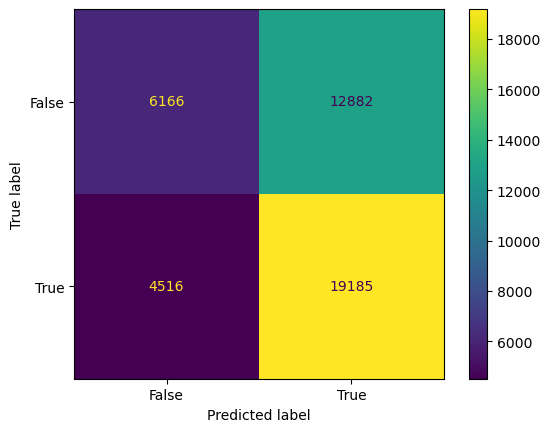

In [37]:
# Confision Matrix
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_preds)

display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=log_r.classes_)

display.plot()

In [41]:
TP = 8150
TN = 2609
FN = 1929
FP = 5633

accuracy = (TP + TN) / (TP + TN + FN + FP)
precision = TP / (TP + FP)
recall =  TP/ (TP + FN)
f1_score = (2 * (precision * recall)) / (precision + recall)

print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1_Score: {f1_score}')


Accuracy: 0.5872496042792424
Precision: 0.5913081332075746
Recall: 0.8086119654727651
F1_Score: 0.6830944598105776


In [43]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

print(f"Sklearn's accuracy: {accuracy_score(y_test, y_preds)}")
print(f"Sklearn's precision: {precision_score(y_test, y_preds)}")
print(f"Sklearn's recall: {recall_score(y_test, y_preds)}")
print(f"Sklearn's f1_score: {f1_score(y_test, y_preds)}")

Sklearn's accuracy: 0.5930197197595265
Sklearn's precision: 0.5982786041725138
Sklearn's recall: 0.809459516476098
Sklearn's f1_score: 0.6880289771912208


### Where the f1_score matters
- when you consider both false positive and false negative,
- imbalanced dataset
- interest to have a balanced dataset
- when you want a balance metrics


In [44]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

       False       0.58      0.32      0.41     19048
        True       0.60      0.81      0.69     23701

    accuracy                           0.59     42749
   macro avg       0.59      0.57      0.55     42749
weighted avg       0.59      0.59      0.57     42749



- **True Positive** - When our model predicts poisonous when its actually poisonous.
- **False Positive** - When our model predicts poisonous when its actually edible
- **False Negative** - When our model predicts edible when its actually poisonous.
- **True Negative** - When our model predicts edible when its actually edible.

## Classification Metrics
- **Total Preeicted Positives** -- all the mushrooms that were predicted as posonous irregardless of whether it was or was not ('TP' & 'TP')
- **Total/Actual predictives** --- all the mushrooms that were poisonous whether or not correctly classified
- **Total Observations** ---